# Example 8: Analysis Involving Multiple Tracers
In this example, we benchmark simulation results from ISOSIMpy against equivalent results obtained from TracerLPM. We consider the tracer input data given in Example 1 of the TracerLPM documentation [(Jurgens et al., 2012)](https://pubs.usgs.gov/publication/tm4F3).

In [1]:
import ISOSIMpy.model as ism
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

## 1. Load (Synthetic) Observation Data
See Example 5 on how this data is generated.

In [2]:
# load input series
# this would be the tracer concentration in precipitation or recharge in a
# practical problem
file_name = "TracerLPM_benchmark_input_multitracer.csv"
data = np.genfromtxt(
    file_name,
    delimiter=";",
    dtype=["<U7", float, float, float, float, float],
    encoding="utf-8",
    skip_header=1
)

timestamps = np.array([datetime.strptime(row[0], r"%Y-%m") for row in data])
# we only keep 3H and SF6
input_series = np.array([[row[1], row[5]] for row in data], dtype=float)

# load observation series
# this would be the measured tracer concentration in groudnwater in a
# practical problem
file_name = "TracerLPM_benchmark_observations_multitracer.csv"
data = np.genfromtxt(
    file_name,
    delimiter=";",
    dtype=["<U7", float, float, float, float, float],
    encoding="utf-8",
    skip_header=1
)

timestamps = np.array([datetime.strptime(row[0], r"%Y-%m") for row in data])
# we only keep 3H and SF6
obs_series = np.array([[row[1], row[5]] for row in data], dtype=float)

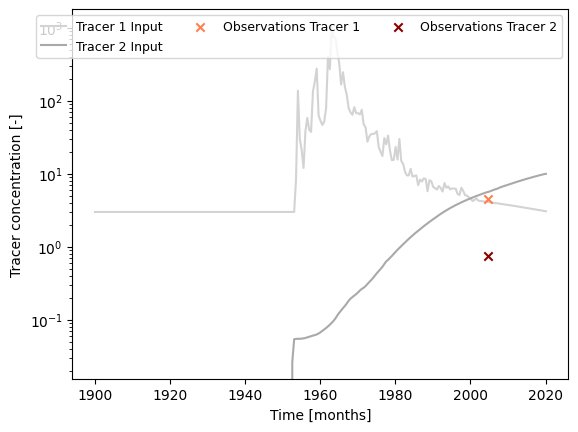

In [3]:
### plot input series, output series, and observations

# get observation timesteps
timesteps = [t.year + t.month / 12.0 for t in timestamps]

# create figure
fig, ax = plt.subplots(1, 1)
# plot input series
ax.plot(
    timesteps,
    input_series[:, 0],
    label="Tracer 1 Input",
    c="lightgrey"
)
ax.plot(
    timesteps,
    input_series[:, 1],
    label="Tracer 2 Input",
    c="darkgrey"
)

# plot observations
ax.scatter(
    timesteps,
    obs_series[:, 0],
    label="Observations Tracer 1",
    color="coral",
    marker="x",
    zorder=10
)
ax.scatter(
    timesteps,
    obs_series[:, 1],
    label="Observations Tracer 2",
    color="darkred",
    marker="x",
    zorder=10
)

ax.set_xlabel("Time [months]")
ax.set_ylabel("Tracer concentration [-]")
ax.legend(ncol=3, fontsize=9)
ax.set_yscale("log")
plt.show()

## 2. Model Setup

In [4]:
t_half = 12.32 # tritium, in years
lambda_1 = np.log(2.0) / t_half

t_half = 1e10 # SF6 (which does not decay)
lambda_2 = np.log(2.0) / t_half

### define model (we do not use the same structure / units as the true model)
# time step is 6 months / 0.5 years
# because we use half life in years, we have to use a time step of 0.5
# if we were to give the half life in months, we would use a time step of 6
m = ism.Model(
    dt=0.5,
    lambda_=[lambda_1, lambda_2],
    input_series=input_series,
    target_series=obs_series,
    steady_state_input=[3., 0.], # this is the true value
    n_warmup_half_lives=10,
    n_warmup_steps=100
)

# add a dispersion model unit
# define the initial model parameters for inference
dm_mtt_init = 10
dm_dp_init = 0.1
m.add_unit(
    ism.DMUnit(mtt=dm_mtt_init, DP=dm_dp_init),
    fraction=1.,
    bounds=[(1.0, 100.), (0.1, 2.0)],
    prefix="dm"
)

In [ ]:
# calibrate model
# create a solver
solver = ism.Solver(m)
res_1_x, res_1 = solver.differential_evolution()

res_1_x

In [5]:
# sample from parameter posterior
# create a solver
solver = ism.Solver(m)
# run MCMC
res = solver.mcmc_sample(
    n_samples=5000, # effective samples after burn-in and thinning
    burn_in=5000,
    thin=2,
    rw_scale=[0.1, 0.1,], # order: DP, mtt
    rw_scale_isotropic=False,
    sigma=0.1,
    random_state=42,
    return_sim=True,
    set_model_state=False
)

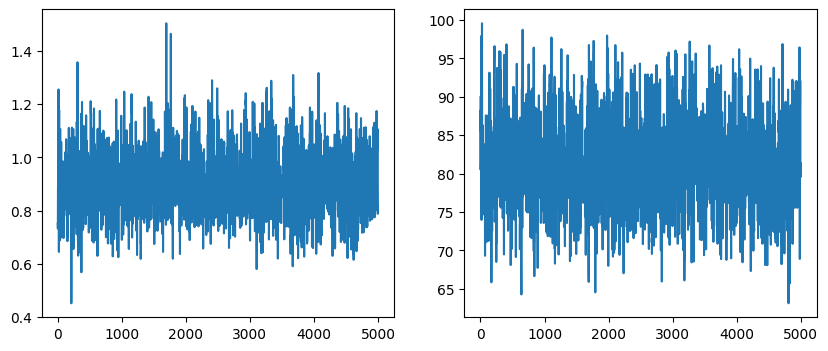

In [6]:
# diagnostic plots
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(res["samples"][:, 0])
ax[1].plot(res["samples"][:, 1])

## 3. Model Simulation for Different Mean Travel Times

In [ ]:
# Define range of mean travel times to consider
mtt_range = np.linspace(10, 100, 51)

# Create empty array of results
results = np.zeros((2, len(mtt_range), len(input_series)))

# Iterate over mean travel times
for i, mtt in enumerate(mtt_range):
    m.set_param(key="dm.mtt", value=mtt)
    sim = m.simulate()
    results[0, i, :] = sim[:, 0].flatten()
    results[1, i, :] = sim[:, 1].flatten()


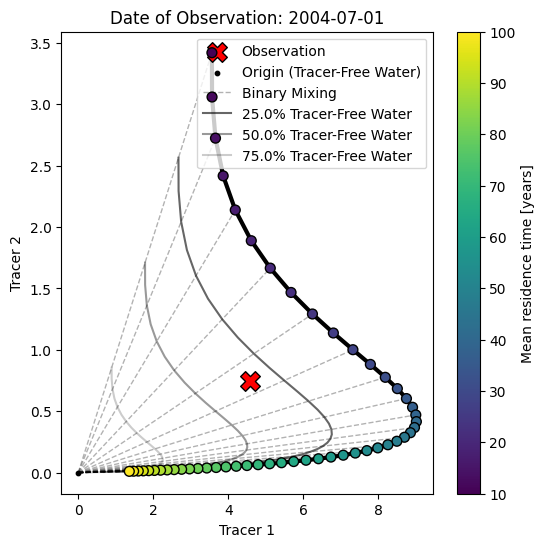

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Get indices of time series that have observations
obs_indices = np.arange(len(timestamps))[~np.isnan(obs_series).any(axis=1)]

# select index of observation date
idx_select = 0

# plot the line connecting the points of different mean travel times
ax.plot(
    results[0, :, obs_indices[idx_select]],
    results[1, :, obs_indices[idx_select]],
    c="black",
    lw=3.
)
# plot the points of different mean travel times and color them by mean
# travel time
im = ax.scatter(
    results[0, :, obs_indices[idx_select]],
    results[1, :, obs_indices[idx_select]],
    c=mtt_range,
    edgecolor="k",
    s=50,
    zorder=10
)
# plot the observation
ax.scatter(
    obs_series[obs_indices[idx_select], 0],
    obs_series[obs_indices[idx_select], 1],
    c="r",
    edgecolor="k",
    marker="X",
    zorder=10,
    s=200,
    label="Observation"
)
# plot the origin point
ax.scatter(
    [0.],
    [0.],
    c="k",
    edgecolor="k",
    marker="o",
    zorder=10,
    s=10,
    label="Origin (Tracer-Free Water)"
)

# plot straight lines from the origin to the points representing the different
# mean travel times
stepper = 2 # plot line from origin to every stepper point
points_idx = [i for i in range(len(mtt_range))][::stepper]
for i in points_idx:
    label = None
    if i == points_idx[0]:
        label = "Binary Mixing"
    ax.plot(
        [0., results[0, i, obs_indices[idx_select]]],
        [0., results[1, i, obs_indices[idx_select]]],
        c="k",
        lw=1.,
        alpha=0.3,
        ls="--",
        label=label
    )

# plot path between points representing the different mean travel times but
# multiplied by a range of dilution factors
percent_tracer_free = [.75, .5, .25]
for p in percent_tracer_free:
    ax.plot(
        results[0, :, obs_indices[idx_select]] * p,
        results[1, :, obs_indices[idx_select]] * p,
        c="k",
        lw=1.5,
        alpha=0.8 * p,
        label=f"{(1-p)*100}% Tracer-Free Water"
    )

plt.colorbar(im, ax=ax, label="Mean residence time [years]")
# ax.set_yscale("log")
# ax.set_xscale("log")
ax.set_xlabel("Tracer 1")
ax.set_ylabel("Tracer 2")
ax.legend()
# include observation date / diagram date as title
ax.set_title(f"Date of Observation: {timestamps[obs_indices[idx_select]].date()}")
plt.show()

### 3.2 Bringing the Analysis to Another Dimension
Here we re-use the results from before for the different mean travel times. But instead of plotting the trajectory of the tracer concentrations valid for a single observation date as before, we plot this diagram for *all* possible observation dates. Because we then have an additional axis or dimension in the data, we need to create a 3D-plot.

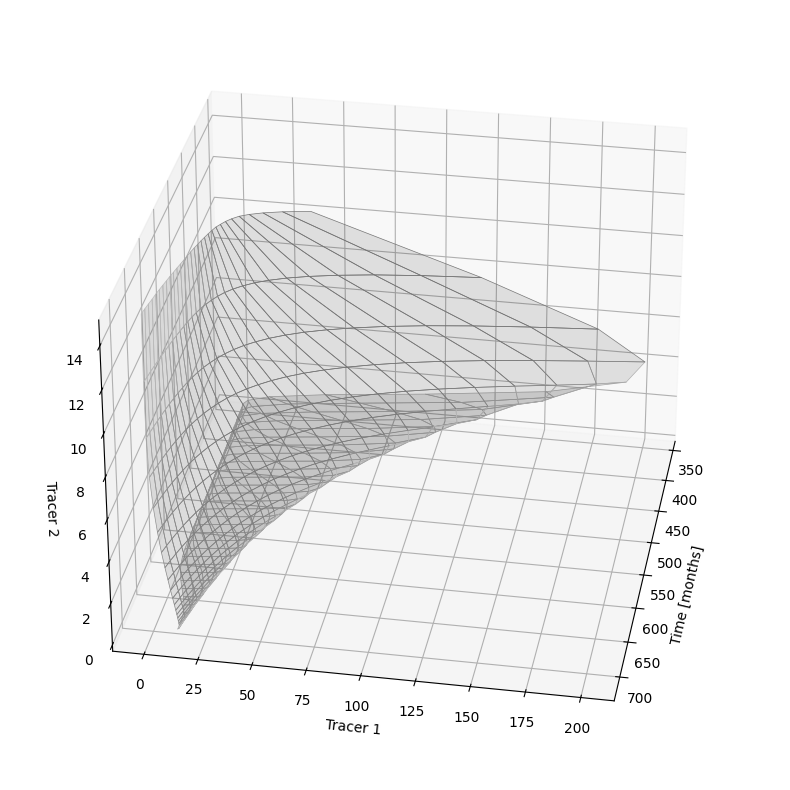

In [ ]:
# make a 3d plot with a combination of tracer-tracer plots at all sample dates
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

start = 12 * 30
stop = 12 * 60
stepper = 12
time_ = [i for i in range(results.shape[2])][start:stop:stepper]
for i in range(len(time_) - 1):
    ax.fill_between(
        x1=[time_[i]],
        y1=results[0, :, time_[i]],
        z1=results[1, :, time_[i]],
        x2=[time_[i+1]],
        y2=results[0, :, time_[i+1]],
        z2=results[1, :, time_[i+1]],
        facecolors="k",
        edgecolors="lightgrey",
        linewidth=0.5,
        alpha=0.1
    )

ax.set_xlabel("Time [months]")
ax.set_ylabel("Tracer 1")
ax.set_zlabel("Tracer 2")

# rotate 3d plot
ax.view_init(30, 10)